# TP4 :  Low-budget  Learning

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data are available for training, say

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. Hence we are not in the context of classical well-organized benchmark datasets.

To make your life easier, you also get a validation set $\mathcal{X}_{\text{val}}$ representative of the test set, but you cannot use it for training. You can only use it to select the best model and hyperparameters.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. We also assume that we have a limited computational budget (e.g., limited GPU access).


In this practical, we will use the `resnet10` architecture.

# QUESTIONS

## Grading

You will need to provide 4 files :
1. This Notebook
2. `utils.py`
3. `drawing_lora.png`
4. `cutmix.png`

Some of the code will be automatically graded so please follow the instructions carefully.

You will also need to participate in a competition on https://www.codabench.org to get your model evaluated on the hidden test set (the link to the competition will be provided on the course forum). Before submitting anything make sure to read the instructions on the competition page. The evaluation metric is the accuracy. However, *this is not a competition* as it is not necessary to get the best score to get a good grade. If you get a good score, and follow the instructions, you will get a good grade.

`utils.py` will be imported during the testing phase so please make sure:
- it does not execute any code when imported
- it does not depend on any module that is not standard (e.g., not `torch`, `torchvision`, `numpy`, etc.)


General instructions:
- Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).
- For each question that involves training a model:
    - Give the number of trained parameters.
    - You must provide the training curves (train & validation accuracy/loss vs epochs) in the notebook.
    - You must explain the choices you made (hyperparameters, etc). (A short justification is enough. For instance, "I used default hyperparameters." does not need further explanation. Or "I tried (0.1,0.01,0.001) and picked 0.01 because it gave the best validation accuracy." is enough.)
    - You must comment on the accuracy obtained.
- If you use a seed for reproducibility, please make sure it is a personal one using something like `hash("your_firstname_your_lastname")`.

<div class="alert alert-info">  Example of answer  </div>

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.3 MB/s eta 0:00:00


In [2]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
from torchmetrics.classification import ConfusionMatrix


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/MyDrive/DeepLearningInPracticeMVA/TP4

Mounted at /content/drive


In [14]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
if not os.path.exists("data/TP4_images/north_dataset_test"):
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"

--2026-03-01 18:29:22--  https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip
Resolving nextcloud.lisn.upsaclay.fr (nextcloud.lisn.upsaclay.fr)... 129.175.8.8
Connecting to nextcloud.lisn.upsaclay.fr (nextcloud.lisn.upsaclay.fr)|129.175.8.8|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://nextcloud.lisn.upsaclay.fr/public.php/dav/files/yzQRWE2YjmFn9WA/?accept=zip [following]
--2026-03-01 18:29:23--  https://nextcloud.lisn.upsaclay.fr/public.php/dav/files/yzQRWE2YjmFn9WA/?accept=zip
Reusing existing connection to nextcloud.lisn.upsaclay.fr:443.
HTTP request sent, awaiting response... 200 OK
Length: 678531 (663K) [application/zip]
Saving to: ‘north_dataset_train.zip’

north_dataset_train 100%[===================>] 662.63K   957KB/s    in 0.7s    

2026-03-01 18:29:24 (957 KB/s) - ‘north_dataset_train.zip’ saved [678531/678531]

Archive:  north_dataset_train.zip
   creating: north_dataset_sample/
   creat

In [15]:
import os
import urllib.request
import zipfile

# os.makedirs with exist_ok=True is a cleaner way to create nested directories safely
os.makedirs("data/TP4_images", exist_ok=True)

dir_path = "data/TP4_images/"
test_dir = os.path.join(dir_path, "north_dataset_test")

train_url = "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip"
test_url = "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip"

train_zip_path = os.path.join(dir_path, "north_dataset_train.zip")
test_zip_path = os.path.join(dir_path, "north_dataset_test.zip")

# Only download and extract if the test directory doesn't exist
if not os.path.exists(test_dir):
    print("Downloading train dataset... (this might take a moment)")
    urllib.request.urlretrieve(train_url, train_zip_path)
    print("Extracting train dataset...")
    with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dir_path)

    print("Downloading test dataset...")
    urllib.request.urlretrieve(test_url, test_zip_path)
    print("Extracting test dataset...")
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dir_path)

    print("Download and extraction complete!")
else:
    print("Datasets already exist. Ready to go!")

Datasets already exist. Ready to go!


In [16]:
val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)

train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)


metric = ConfusionMatrix(task="multiclass", num_classes=2).to(device)


def model_instancier(**kwargs):
    """
    Instanciate a ResNet10 model (ResNet18 with only 1 block per layer).

    Parameters
    ----------
    **kwargs: dict
        Keyword arguments to pass to the ResNet18 constructor.

    Returns
    -------
    model: nn.Module
        The instantiated ResNet10 model.
    """
    _model = models.resnet18(**kwargs)
    for i in range(1, 5):
        setattr(_model, f"layer{i}", getattr(_model, f"layer{i}")[0])
    return _model


base_model = model_instancier()
classifier_name = "fc"


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 42
Validation dataset size: 42


## Question 1:
>  Create `last_layer.py` to change the last layer of the resnet model so that it fits the problem.

In [17]:
from last_layer import LastLayer

setattr(base_model, classifier_name, LastLayer())
assert (
    getattr(base_model, classifier_name).out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/TP4

/content/drive/MyDrive/TP4


## Question 2:
> Provide a function `precompute_features` in `utils.py` that creates a new dataset from the features precomputed by the model.

In [19]:
from torch.utils.data import DataLoader, TensorDataset


def precompute_features(
    model: nn.Module, dataset: torch.utils.data.Dataset, device: torch.device
) -> torch.utils.data.Dataset:
    """Precomputes the features from the ResNet model for the given dataset.

    Args:
        model: The ResNet model with the final layer replaced by Identity.
        dataset: The dataset for which to precompute features.
        device: The device (CPU or GPU) to perform computations on.
    """
    # Set the model to evaluation mode
    model.eval()
    model = model.to(device)

    # Temporarily replace the final layer with Identity to extract features
    original_fc = model.fc
    model.fc = nn.Identity()

    # DataLoader to process the dataset (pq 64?)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

    all_features = []
    all_labels = []

    # Extract features without computing gradients !
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            # Extract features: outputs shape (batch_size, 512)
            features = model(images)

            # Move features to CPU so we don't run out of GPU memory
            # when storing the entire dataset
            all_features.append(features.cpu())
            all_labels.append(labels.cpu())

    # Restore the original final layer to the model
    model.fc = original_fc

    # Concatenate all batches into single tensors
    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # Return a TensorDataset wrapping the precomputed data
    return TensorDataset(all_features, all_labels)

## Question 3:
> Train the last layer of a randomly initialized resnet model.  Provide the training process in the notebook with training curve. Comment on the accuracy.

In [23]:
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader

In [ ]:
def train_and_evaluate_classifier(
    train_features,
    val_features,
    classifier_layer,
    device,
    num_epochs=20,
    batch_size=32,
    lr=0.001
):
    """
    Trains a linear classifier on precomputed features and plots the learning curves.
    """
    train_loader = DataLoader(train_features, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_features, batch_size=batch_size, shuffle=False)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier_layer.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("Starting training on ImageNet precomputed features...")

    # Training Loop
    for epoch in range(num_epochs):
        classifier_layer.train()
        running_loss, correct, total = 0.0, 0, 0

        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = classifier_layer(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            # Loss by image
            running_loss += loss.item() * features.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        # Valdiation
        classifier_layer.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = classifier_layer(features)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * features.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)

        # Print progress every 5 epochs and on the first epoch
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{num_epochs} - "
                  f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

    # Plots
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Loss over Epochs (Pretrained base)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='orange')
    plt.title('Accuracy over Epochs (Pretrained base)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return history

In [ ]:
from utils import precompute_features

In [ ]:
base_model = model_instancier()
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

Starting training on ImageNet precomputed features...
Epoch 01/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 05/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 10/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 15/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 20/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 25/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 30/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 35/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 40/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 45/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 50/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 55/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 60/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 65/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 70/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 75/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 80/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 85/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 90/200 - Train Acc: 0.

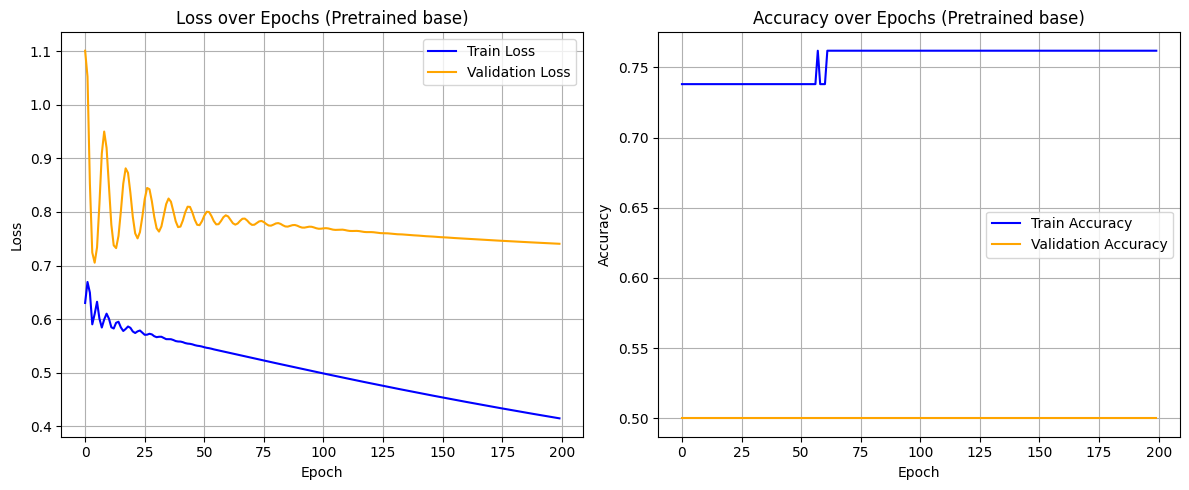

In [ ]:
history = train_and_evaluate_classifier(
    train_features=train_features_dataset,
    val_features=val_features_dataset,
    classifier_layer=getattr(base_model, classifier_name),
    device=device,
    num_epochs=200,
    batch_size=64,
    lr=0.01)

We tried values in {0.1, 0.01, 0.001} for the learning rate and picked 0.01 because it gave the most decrease in the validation loss. We chose a batch size of 64 to have a good balance between training speed and stability : the lower the batch size, the more oscillations in the training curve. We trained for 20 epochs, which is enough for the training loss to stabilize.

1. Validation Accuracy at 50% (Random Guessing): Since this is a binary classification task (2 classes), a 50% validation accuracy means the model is performing no better than a random coin flip. This is exactly what we expect. Because the base ResNet model was randomly initialized and frozen, its convolutional layers (g(x)) are not extracting any meaningful visual features (like edges or textures). It is essentially outputting a random 512-dimensional vector for every image.

2. Training Accuracy at ~74% (Overfitting to Noise): The linear classifier (our LastLayer) is trying to find a boundary to separate the two classes based on these random 512-dimensional vectors. Because 512 dimensions give the model a lot of mathematical flexibility, it manages to memorize some random noise patterns in the training data, pushing the training accuracy to ~74%. However, because these patterns are purely random and have nothing to do with the actual images, this "knowledge" completely fails to generalize to the validation set.

Conclusion: Training only the last layer of a randomly initialized feature extractor does not work. For this approach to be effective, the base model needs to be pre-trained on a large dataset so it can provide meaningful representations to the final layer.

## Question 4:
>  Now start from a pretrained model on imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve.

This is the first question evaluated on the codabench platform.

In [ ]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

In [ ]:
train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

Starting training on ImageNet precomputed features...
Epoch 01/200 - Train Acc: 0.3095 - Val Acc: 0.5000
Epoch 05/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 10/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 15/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 20/200 - Train Acc: 0.8810 - Val Acc: 0.6905
Epoch 25/200 - Train Acc: 0.8571 - Val Acc: 0.6190
Epoch 30/200 - Train Acc: 0.8810 - Val Acc: 0.6905
Epoch 35/200 - Train Acc: 0.9048 - Val Acc: 0.7143
Epoch 40/200 - Train Acc: 0.8810 - Val Acc: 0.7143
Epoch 45/200 - Train Acc: 0.9286 - Val Acc: 0.7619
Epoch 50/200 - Train Acc: 0.9286 - Val Acc: 0.7619
Epoch 55/200 - Train Acc: 0.9286 - Val Acc: 0.7619
Epoch 60/200 - Train Acc: 0.9286 - Val Acc: 0.7857
Epoch 65/200 - Train Acc: 0.9524 - Val Acc: 0.7857
Epoch 70/200 - Train Acc: 0.9524 - Val Acc: 0.8095
Epoch 75/200 - Train Acc: 0.9524 - Val Acc: 0.8095
Epoch 80/200 - Train Acc: 0.9524 - Val Acc: 0.8095
Epoch 85/200 - Train Acc: 0.9524 - Val Acc: 0.8333
Epoch 90/200 - Train Acc: 0.

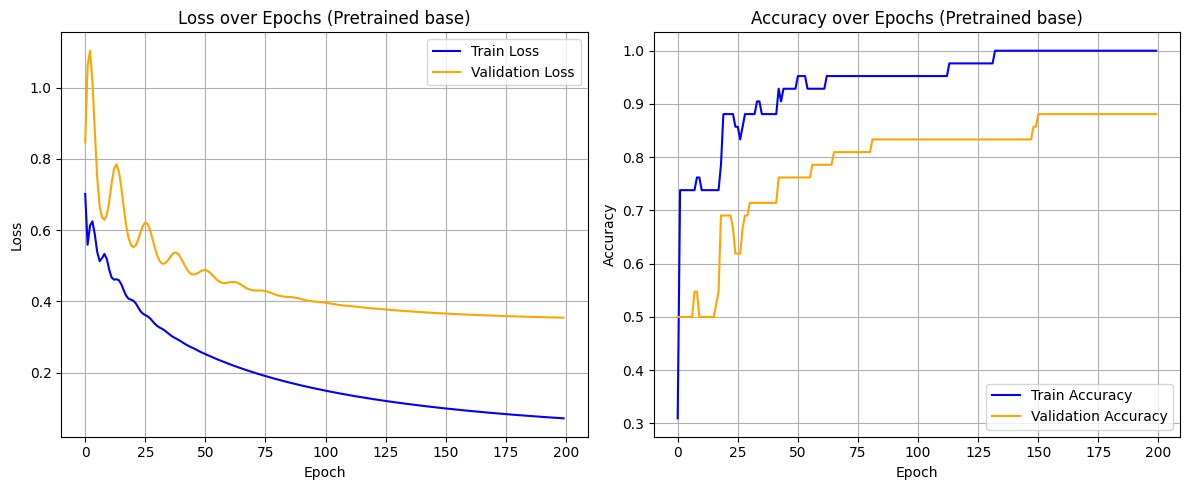

In [ ]:
# Extract the classifier layer to pass into our function
classifier = getattr(base_model, classifier_name).to(device)

# Train the layer and plot the results
history = train_and_evaluate_classifier(
    train_features=train_features_dataset,
    val_features=val_features_dataset,
    classifier_layer=classifier,
    device=device,
    num_epochs=200,
    batch_size=64,
    lr=0.01
)

<div class="alert alert-info">  You should achieve >80% accuracy on the val set.  </div>

We use 0.01 as learning rate because the loss decreases well with this value and we get a good validation accuracy. We also tested with 0.001 and lower learning rates but we get a lower validation accuracy. As previous question, we use a batch size of 64 to have a good balance between training speed and stability. We trained for 200 epochs which proves enough for the validation accuracy to stabilize.

We reach a validation accuracy of 88.10% which is quite a good performance. This shows that the features extracted by the pretrained ResNet model are very useful for our classification task, where we only trained the last layer. This is a common phenomenon in transfer learning, where a model pre-trained on a large dataset can provide powerful feature representations that can be used for different tasks with limited training data.

### Save your model

In [ ]:
# Save the last layer weights for grading on codabench
torch.save(getattr(base_model, classifier_name).state_dict(), "last_layer_finetune.pth")

### Check that you can load your model

In [ ]:
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(
    torch.load("last_layer_finetune.pth", weights_only=True, map_location=device)
)
setattr(model, classifier_name, fc)
model.eval()
pass

## Question 5:
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  ( We are perfectly fine if you use external library for this question only )

Intermediate question : Describe LoRA and the difference with LoRA for Convolutions in this paper : https://arxiv.org/pdf/2401.17868  in a few lines  (you do not have to implement ConvLora)

In [61]:
from peft import LoraConfig, get_peft_model

# Start fresh with a pretrained model and our custom last layer
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())

# LoRA Configuration
lora_config = LoraConfig(
    r=8,                  # Rank of the update matrices (lower = fewer parameters)
    lora_alpha=16,        # Scaling factor for the LoRA updates
    target_modules=["conv1", "conv2"], # Targets the Conv2d layers in ResNet blocks
    lora_dropout=0.1,     # Dropout probability for LoRA layers
    bias="none",          # Bias handling
    modules_to_save=[classifier_name] # Tells PEFT to keep our custom fc layer fully trainable!
)

# Wrap the base model with the LoRA model
lora_model = get_peft_model(base_model, lora_config)
lora_model = lora_model.to(device)

# Print the parameter reduction to see the advantage of LoRA
lora_model.print_trainable_parameters()

trainable params: 124,058 || all params: 5,030,876 || trainable%: 2.4659


In [62]:
def train_lora_model(
    model,
    train_data,
    val_data,
    device,
    num_epochs=10,
    batch_size=32,
    lr=0.001
):

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # loss and optimizer
    # Notice we pass model.parameters() because PEFT automatically handles
    # freezing the base weights and only passing the LoRA + classifier weights to the optimizer.
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("Starting LoRA fine-tuning on raw images...")

    # Training Loop
    for epoch in range(num_epochs):
        # Training-
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            # Forward pass now goes through the entire ResNet + LoRA layers
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        # Validation
        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)

        print(f"Epoch {epoch+1:02d}/{num_epochs} - "
              f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")


    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='purple')
    plt.plot(history['val_loss'], label='Validation Loss', color='green')
    plt.title('Loss over Epochs (LoRA)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='purple')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Accuracy over Epochs (LoRA)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return history

Starting LoRA fine-tuning on raw images...
Epoch 01/250 - Train Acc: 0.2619 - Val Acc: 0.3571
Epoch 02/250 - Train Acc: 0.2619 - Val Acc: 0.4762
Epoch 03/250 - Train Acc: 0.2619 - Val Acc: 0.5476
Epoch 04/250 - Train Acc: 0.2619 - Val Acc: 0.5000
Epoch 05/250 - Train Acc: 0.2857 - Val Acc: 0.5000
Epoch 06/250 - Train Acc: 0.2857 - Val Acc: 0.5000
Epoch 07/250 - Train Acc: 0.3095 - Val Acc: 0.5238
Epoch 08/250 - Train Acc: 0.3333 - Val Acc: 0.5238
Epoch 09/250 - Train Acc: 0.3333 - Val Acc: 0.5476
Epoch 10/250 - Train Acc: 0.3333 - Val Acc: 0.5476
Epoch 11/250 - Train Acc: 0.3333 - Val Acc: 0.5476
Epoch 12/250 - Train Acc: 0.3810 - Val Acc: 0.5476
Epoch 13/250 - Train Acc: 0.3810 - Val Acc: 0.5476
Epoch 14/250 - Train Acc: 0.4048 - Val Acc: 0.5476
Epoch 15/250 - Train Acc: 0.4286 - Val Acc: 0.5476
Epoch 16/250 - Train Acc: 0.4762 - Val Acc: 0.5476
Epoch 17/250 - Train Acc: 0.4762 - Val Acc: 0.5476
Epoch 18/250 - Train Acc: 0.4762 - Val Acc: 0.5952
Epoch 19/250 - Train Acc: 0.5000 - Val 

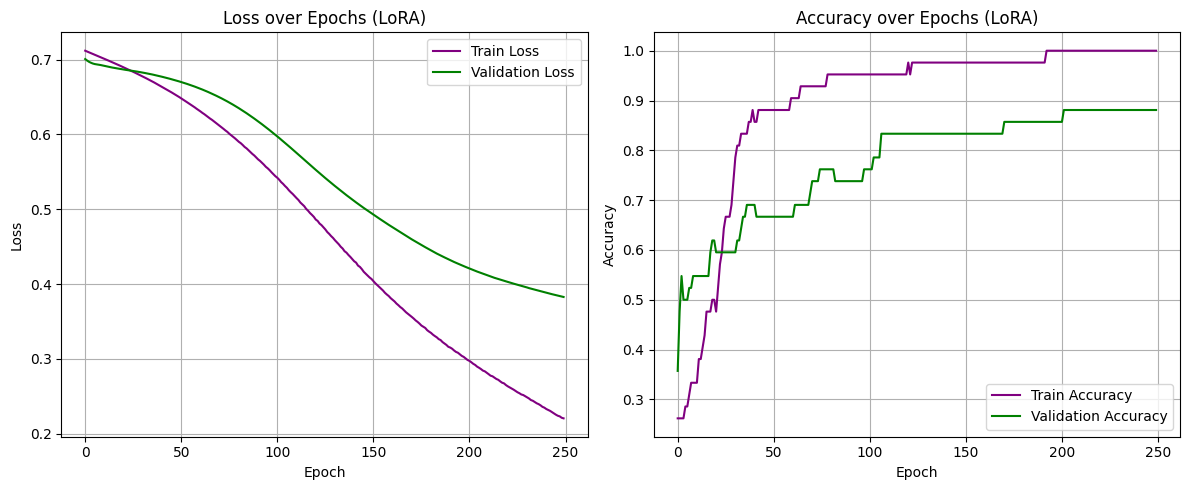

In [ ]:
# We use fewer epochs here because full-image passes take longer,
# and LoRA usually converges quite efficiently.
lora_history = train_lora_model(
    model=lora_model,
    train_data=train_dataset,
    val_data=val_dataset,
    device=device,
    num_epochs=250,
    batch_size=64,
    lr=0.00005
)

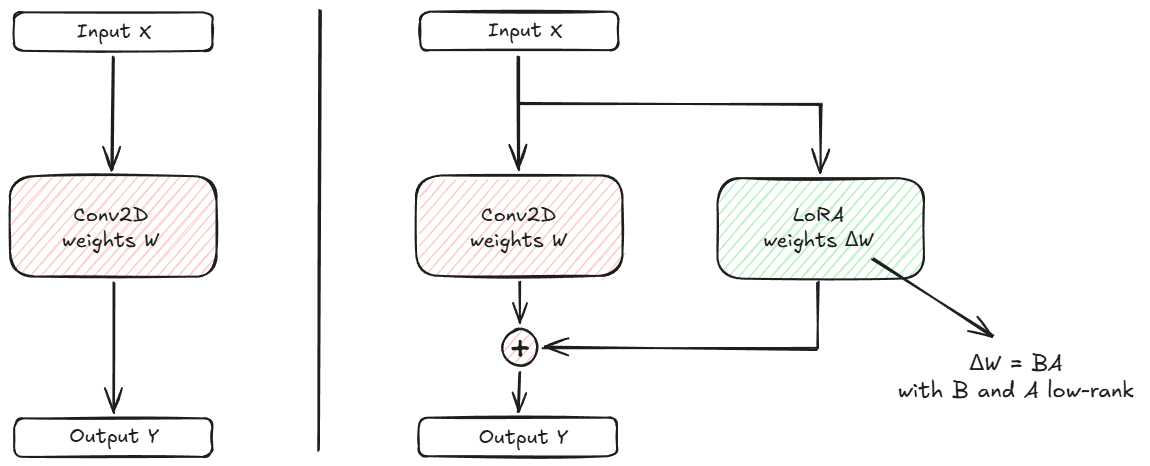

In [2]:
from IPython.display import Image, display
display(Image('C:/Users/perni/Downloads/lora.png', width=2000))

Low-Rank Adaptation or LoRA is a parameter-efficient fine-tuning technique (PEFT) that adapts large pre-trained models by freezing their original weights and injecting small, trainable rank decomposition matrices into each layer of the transformer architecture. The injected weight matrix is composed of a linear encoder and a linear decoder. LoRA reduces computational overhead compared to full fine-tuning and helps recover high-level semantic information using purely linear projections. 

There are different ways to apply LoRA to convolutional layers. The implementation that we use here is the one proposed in the original LoRA paper, where the convolutional layer is treated as a linear layer. We thus apply the same linear decomposition as for the fully connected layers. However, this approach may not be optimal for convolutional layers, which have a different structure and by adding only a linear decomposition, it sometimes lacks vision-specific inductive biases that may be necessary for understanding spatial relationships in images for examples. 

To solve this, the given article introduce Conv-LoRA, which distinguishes itself from LoRA by inserting lightweight convolution operations into the low-rank bottleneck between the encoder and decoder components. Because objects in images vary in size, Conv-LoRA does not just apply a simple convolution but it uses a dynamic MoE routing mechanism : multiple parallel "expert" modules are deployed, each specializing in a distinct feature scale by first interpolating the feature map to a specific size, applying a 3x3 convolution to capture local priors, and then resizing it back to the default scale. By local priors, the authors mean that neighboring pixels are often strongly correlated. A compact gating network analyzes the input data and dynamically activates the most appropriate expert for that specific image scale during the forward pass, which allows Conv-LoRA to inject multi-scale inductive biases into the model without increasing to much the number of parameters.

There is a high risk of overfitting as we train LoRA on a small dataset. We use a learning rate of 0.00005 because LoRA works better with smaller learning rates and we want to avoid overfitting. With higher learning rates the validation loss end up increasing which indicates overfitting. We also use a batch size of 64 to have a good balance between training speed and stability. We trained for 250 epochs because with a smaller learning rate, the training process is slower and it takes more epochs for the validation accuracy to stabilize.

## Question 6:
> Let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them into your training pipeline.

Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing.

You can find many other data augmentation techniques here: https://docs.pytorch.org/vision/0.15/transforms.html

This is the second question evaluated on the codabench platform.

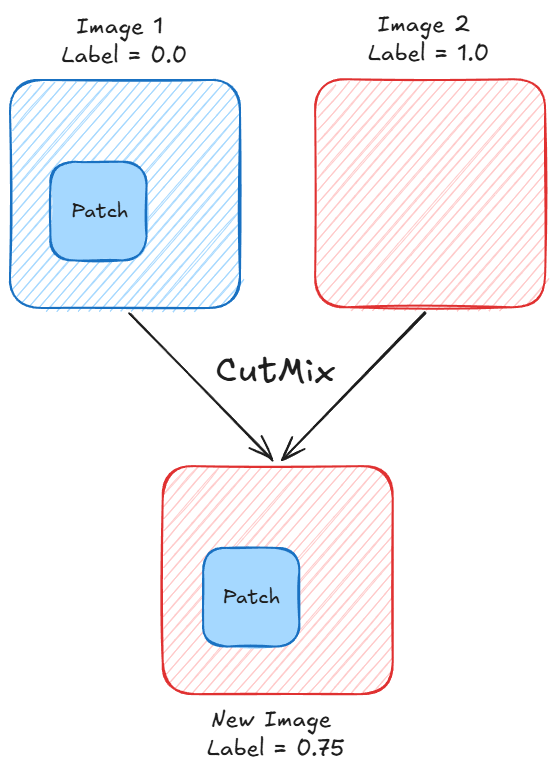

In [ ]:
from IPython.display import Image, display
display(Image('/content/drive/MyDrive/cutmix.png', width=600))

CutMix is a data augmentation technique that creates new training samples by combining two existing samples. It works by randomly selecting two images and their corresponding labels, then cutting a random patch from one image and pasting it onto the other image. The labels are also mixed proportionally to the area of the patch. This encourages the model to learn from both images and can improve generalization.

In [202]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())

# LoRA Configuration
lora_config = LoraConfig(
    r=8,                  # Rank of the update matrices (lower = fewer parameters)
    lora_alpha=16,        # Scaling factor for the LoRA updates
    target_modules=["conv1", "conv2"], # Targets the Conv2d layers in ResNet blocks
    lora_dropout=0.1,     # Dropout probability for LoRA layers
    bias="none",          # Bias handling
    modules_to_save=[classifier_name] # Tells PEFT to keep our custom fc layer fully trainable!
)

# Wrap the base model with the LoRA model
lora_model_aug = get_peft_model(base_model, lora_config)
lora_model_aug = lora_model_aug.to(device)

# Print the parameter reduction to see the advantage of LoRA
lora_model_aug.print_trainable_parameters()

trainable params: 124,058 || all params: 5,030,876 || trainable%: 2.4659


In [203]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


# Chargement des datasets
train_dataset_aug = datasets.ImageFolder("data/TP4_images/north_dataset_sample", transform=train_transform)
val_dataset = datasets.ImageFolder("data/TP4_images/north_dataset_test", transform=val_transform)

train_loader = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
from torchvision.transforms import v2

def train_lora_model_with_cutmix(
    model,
    train_data,
    val_data,
    device,
    num_epochs=10,
    batch_size=32,
    lr=0.001
):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # Le critère CrossEntropyLoss gère nativement les labels de CutMix (probabilités)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("Starting LoRA fine-tuning with CutMix...")

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)

        print(f"Epoch {epoch+1:02d}/{num_epochs} - "
              f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

    # Affichage des courbes
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='purple')
    plt.plot(history['val_loss'], label='Validation Loss', color='green')
    plt.title('Loss (LoRA + CutMix)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='purple')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Accuracy (LoRA + CutMix)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return history

Starting LoRA fine-tuning with CutMix...
Epoch 01/300 - Train Acc: 0.7381 - Val Acc: 0.5238
Epoch 02/300 - Train Acc: 0.7381 - Val Acc: 0.5238
Epoch 03/300 - Train Acc: 0.7619 - Val Acc: 0.5476
Epoch 04/300 - Train Acc: 0.7857 - Val Acc: 0.5714
Epoch 05/300 - Train Acc: 0.7381 - Val Acc: 0.5714
Epoch 06/300 - Train Acc: 0.7619 - Val Acc: 0.5714
Epoch 07/300 - Train Acc: 0.8095 - Val Acc: 0.5238
Epoch 08/300 - Train Acc: 0.7857 - Val Acc: 0.5238
Epoch 09/300 - Train Acc: 0.7619 - Val Acc: 0.5238
Epoch 10/300 - Train Acc: 0.7857 - Val Acc: 0.5238
Epoch 11/300 - Train Acc: 0.8095 - Val Acc: 0.5476
Epoch 12/300 - Train Acc: 0.7857 - Val Acc: 0.5476
Epoch 13/300 - Train Acc: 0.8333 - Val Acc: 0.5476
Epoch 14/300 - Train Acc: 0.8333 - Val Acc: 0.5714
Epoch 15/300 - Train Acc: 0.7857 - Val Acc: 0.5476
Epoch 16/300 - Train Acc: 0.8333 - Val Acc: 0.5476
Epoch 17/300 - Train Acc: 0.7619 - Val Acc: 0.5476
Epoch 18/300 - Train Acc: 0.8095 - Val Acc: 0.5476
Epoch 19/300 - Train Acc: 0.8333 - Val Ac

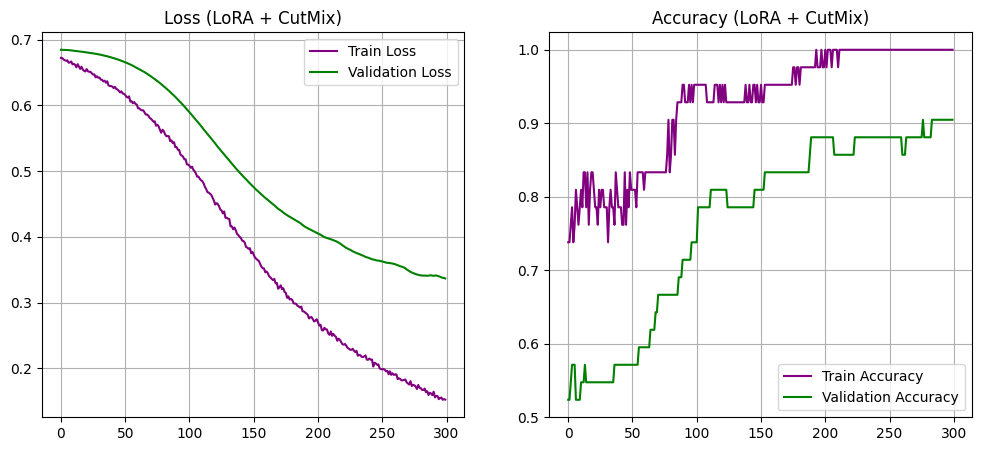

In [205]:
lora_history = train_lora_model_with_cutmix(
    model=lora_model_aug,
    train_data=train_dataset_aug,
    val_data=val_dataset,
    device=device,
    num_epochs=300,
    batch_size=64,
    lr=0.00005
)

We didn't use CutMix because it was too random and it made the training process unstable. We used random cropping and horizontal flipping instead, which are more standard data augmentation techniques for image classification tasks. These augmentations help the model generalize better by providing it with more varied training examples without introducing too much randomness that could destabilize the training process.

We use more epochs than before because data augmentation makes the training process more complex and it takes more time for the model to learn from the augmented data. With more epochs, the model has more opportunities to see the augmented data and learn from it, which can lead to better performance on the validation set. Furthermore, with data augmentation, the model is less likely to overfit, so we can afford to train for more epochs without worrying about overfitting as much as before. 

In the end, we obtain a validation accuracy of 90.48%, which is a slight improvement over the previous 88.10% without data augmentation. This shows that the augmentations we applied helped the model generalize better to the validation set, even though we didn't use CutMix specifically. It is also better than the 88.10% that we obtained by training only the last layer without data augmentation, which demonstrates the benefits of combining LoRA with data augmentation in improving model performance.

### Save your model

In [206]:
# Merge LoRA weights back into the base model
merged_model = lora_model_aug.merge_and_unload().to('cpu')
assert isinstance(merged_model, models.ResNet)

torch.save(merged_model.state_dict(), "final_model.pth")

### Check that you can load your model

In [207]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel

<div class="alert alert-info">  With LoRA and Data Augmentation you should be able to improve your model's performance compared to only fine-tuning the last layer. </div>

# Some advice

In our experiments, we only used SGD and a laptop GPU. We recommend not hesitating to use a large number of epochs (e.g., 100, 200, etc.). We did not use any learning rate scheduler but you can try if you want. Many data augmentation techniques exist, you can try them and see if they improve your performance. You can also try to combine them. For instance, you can try to combine CutMix with some geometric transformations (e.g., random crop, random horizontal flip, etc.).

The improvement from LoRA and data augmentation is quite hard to see on the small validation set. If you get even a small improvement on the validation set, it is likely that you will get a better score on the test set, except if you overfit the validation set. With an honest improvement on the validation set, you should be able to get a good grade.

In [ ]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

In [ ]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(torch.load("last_layer_finetune.pth", weights_only=True, map_location=device))
setattr(model, classifier_name, fc)
model.eval()